## Project environment

In [22]:
# Importing libraries
from pathlib import Path
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Project root (current working) directory
project_root = Path.cwd().parent

# Define project directory
data_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"

## Load processed (aggregated) data

In [23]:
aggregated_data = "aggregated_supplier_df.parquet" # Aggregated data filename
agg_df = pd.read_parquet(processed_dir / aggregated_data) # Read Parquet file

## Feature selection and scaling

In [24]:
# Selecting model features
features = ["total_spend_log", "total_invoices_log", "avg_invoice_amount"]
X_agg = agg_df[features].copy()

# Apply scaling to standardize feature values
scaler = StandardScaler()
agg_scaled = scaler.fit_transform(X_agg)

## Model parameters

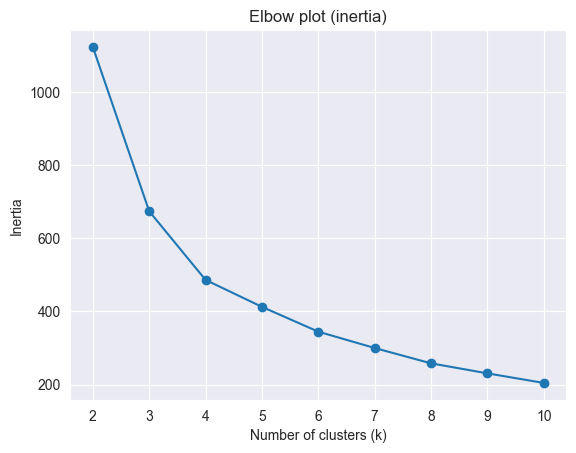

In [25]:
# Apply Elbow method for selecting number of clusters
inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=26)
    kmeans.fit(agg_scaled)
    inertia.append(kmeans.inertia_)

# Visualize Elbow output
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow plot (inertia)")
plt.show()

## Run k-means clustering

In [26]:
# Run k-means with k clusters
k = 3
kmeans = KMeans(
    n_clusters=k,
    random_state=26
)
agg_df['cluster'] = kmeans.fit_predict(agg_scaled)

# Add cluster labels to the df
cluster_labels = {
    2: "Strategic suppliers",
    0: "High-value suppliers",
    1: "Tail suppliers"
}
agg_df['cluster_label'] = agg_df['cluster'].map(cluster_labels)

## Validation

In [27]:
# Silhouette score
score = silhouette_score(agg_scaled, agg_df["cluster"])
print("Silhouette score:", round(score, 3))

# Summary table
cluster_summary = (
    agg_df
    .groupby("cluster_label")
    .agg(
        suppliers=("supplier_id", "count"),
        total_spend=("total_spend", "sum"),
        total_spend_median=("total_spend", "median"),
        total_invoices=("total_invoices", "sum")
    )
    .round(0)
    .sort_values("total_spend", ascending=False)
)
cluster_summary

Silhouette score: 0.446


,suppliers,total_spend,total_spend_median,total_invoices
cluster_label,,,,
High-value suppliers,243,93462042.0,76885.0,567
Strategic suppliers,76,23362233.0,90654.0,4030
Tail suppliers,297,2051993.0,4977.0,672


## Export results

In [28]:
# Export to CSV
output_file = "supplier_segmentation.csv"
agg_df.to_csv(processed_dir / output_file)

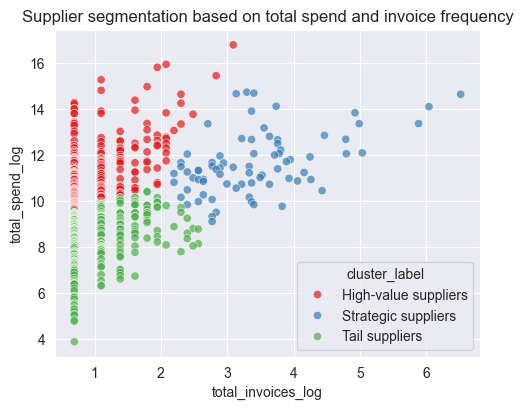

In [29]:
# Visualize supplier clusters

plt.figure(figsize=(5,4))

sns.scatterplot(
    data=agg_df,
    x="total_invoices_log",
    y="total_spend_log",
    hue="cluster_label",
    palette="Set1",
    alpha=0.7
)
plt.tight_layout()
plt.title("Supplier segmentation based on total spend and invoice frequency")

# Save scatterplot
plt.savefig(project_root / "outputs" / "supplier_clusters.png", dpi=300)

plt.show()